In [102]:
import csv

f = open('LOCAL_PEOPLE_DONG_201912.csv', encoding='utf-8')
data = csv.reader(f)
next(data)
data = list(data)
print(len(data))

71232


In [103]:
f2 = open('dong_code.csv', encoding='utf-8')
code_data = csv.reader(f2)
next(code_data)
next(code_data)
code_data = list(code_data)
print(len(code_data))

424


In [104]:
print(data[0])

['20191201', '0', '11215710', '45694.9988', '452.3937', '208.7971', '1267.7678', '5642.9235', '5433.6801', '2494.5993', '1691.4831', '1042.7096', '1058.3378', '895.4639', '875.9212', '601.9097', '496.2165', '850.682', '388.4005', '180.3721', '1586.7039', '6973.6176', '4259.7022', '2036.1446', '1285.42', '794.6241', '833.7179', '772.1417', '773.2152', '827.1455', '565.5378', '1405.3707']


In [105]:
for row in data:
    for i in range(1,8):
        if i <= 2:
            row[i] = int(row[i])
        else:
            row[i] = float(row[i])
print(data[0])

['20191201', 0, 11215710, 45694.9988, 452.3937, 208.7971, 1267.7678, 5642.9235, '5433.6801', '2494.5993', '1691.4831', '1042.7096', '1058.3378', '895.4639', '875.9212', '601.9097', '496.2165', '850.682', '388.4005', '180.3721', '1586.7039', '6973.6176', '4259.7022', '2036.1446', '1285.42', '794.6241', '833.7179', '772.1417', '773.2152', '827.1455', '565.5378', '1405.3707']


In [106]:
for row in code_data:   # 문자열일 때만 변환
    row[1] = int(row[1])

In [107]:
#사용자에게 행정동 명을 입력받고 대응되는 행정동 코드를 찾기
'''
1. 사용자에게서 행정동명을 입력받아 변수(dong_name)에 저장하기
2. 행정동 코드 데이터(code_data)를 돌며 반복하기
    2.1 행정동 코드 데이터의 마지막열인 행정동명이 입력된행정동명이 같다면
        해당하는행정동 코드를 변수에 저장하기 
'''
dong_name = input('핫플레이스가 위차한 행정동을 입력하세요 -->')
dong_code =0
for row in code_data:
    if row[-1] == dong_name:
        dong_code = row[1]
print(dong_name, '-', dong_code,'을 분석합니다!')


핫플레이스가 위차한 행정동을 입력하세요 --> 연희동


연희동 - 11410615 을 분석합니다!


In [108]:
# 시간대별 평균 인구 계산

population = [0] * 24
count = [0] * 24

for row in data:
    if row[2] == dong_code:      # 행정동 코드 비교
        time = row[1]            # 시간 (이미 int 변환됨)
        p = row[3]               # 인구수 (float)
        
        population[time] += p
        count[time] += 1

# 평균 계산
for i in range(24):
    if count[i] != 0:
        population[i] /= count[i]

print(population)

[45746.46845714286, 45934.57357142858, 46010.122671428566, 46138.794214285714, 46419.889, 46339.99434285714, 46141.07884285715, 46251.164000000004, 44084.882600000004, 42135.21284285714, 41045.43172857143, 40278.13628571429, 39445.946285714286, 38521.32428571429, 37983.066600000006, 37202.44737142856, 37298.870642857146, 37423.96948571429, 37779.99005714286, 38272.83971428572, 38909.51245714285, 39518.315500000004, 40557.500328571434, 45386.56948571429]


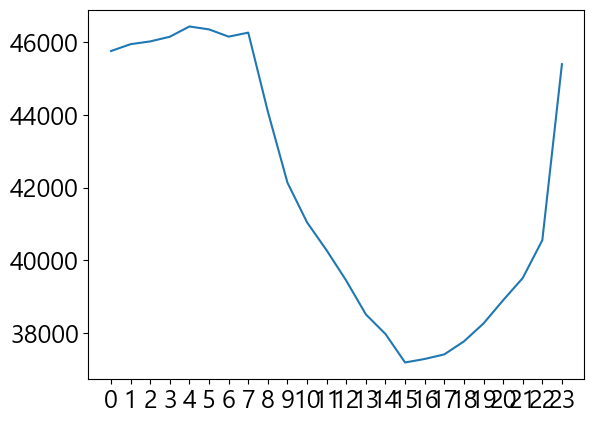

In [109]:
import matplotlib.pyplot as plt

plt.plot(range(24), population)
plt.xticks(range(24))
plt.show()

2019년 12월의 주중 일수 = 22 , 주말 일수 = 9
주중 평균 인구: [10543.17909090909, 10575.965422727275, 10580.842427272726, 10598.538754545456, 10661.242313636363, 10633.552081818183, 10599.086018181819, 10663.101609090909, 10010.304627272728, 9490.107068181818, 9212.335422727272, 8990.498013636365, 8858.308104545455, 8648.867527272727, 8525.721822727273, 8301.304627272726, 8319.318627272727, 8366.110195454547, 8534.893618181819, 8698.934277272727, 8848.995272727274, 8987.381086363637, 9219.887513636366, 10365.925113636364]
주말 평균 인구: [9808.371022222222, 9874.530633333334, 9921.369477777778, 9978.189655555554, 10043.543566666667, 10049.090511111113, 9978.628833333334, 9907.768066666667, 9818.608488888889, 9573.792711111113, 9405.182533333333, 9350.666411111111, 9026.538411111113, 8819.353822222221, 8701.731788888888, 8643.158866666667, 8674.120522222223, 8657.040233333333, 8521.363422222223, 8503.702655555555, 8632.0768, 8767.313844444443, 9007.219666666666, 9961.7371]


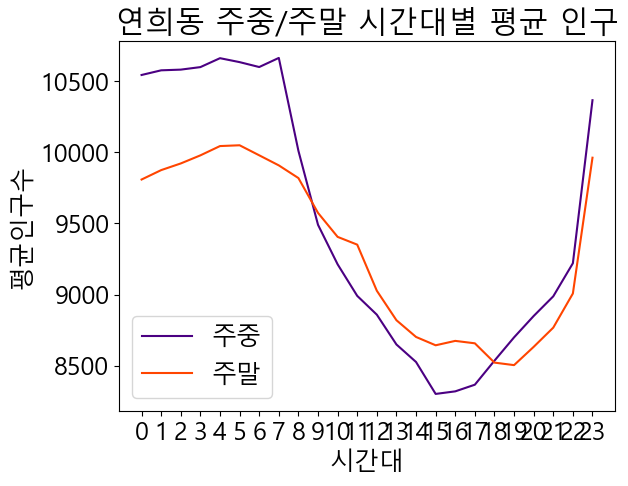

In [110]:
# 2019년 12월의 주중/주말 시간대별 인구수 구하기
weekday = [0 for i in range(24)]
weekend = [0 for i in range(24)]

for row in data:
    if row[2] == dong_code:
        time, p = row[1], row[3]
        year, mon, day = int(row[0][:4]), int(row[0][4:6]), int(row[0][6:])
        num = datetime.date(year, mon, day).weekday()
        if num < 5:
            weekday[time] += p
        else:
            weekend[time] += p

# 2019년 12월의 주중/주말 일수 구하기
weekday_cnt, weekend_cnt = 0, 0
for i in range(1, 32):
    if datetime.date(2019, 12, i).weekday() < 5:
        weekday_cnt += 1
    else:
        weekend_cnt += 1

print('2019년 12월의 주중 일수 =', weekday_cnt, ', 주말 일수 =', weekend_cnt)

# 2019년 12월의 주중/주말 시간대별 평균인구수 구하기
weekday = [w/weekday_cnt for w in weekday]
weekend = [w/weekend_cnt for w in weekend]

print('주중 평균 인구:', weekday)
print('주말 평균 인구:', weekend)

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title(dong_name + ' 주중/주말 시간대별 평균 인구')
plt.plot(range(24), weekday, color = 'indigo', label = '주중')
plt.plot(range(24), weekend, color = 'orangered', label = '주말')
plt.legend()
plt.xlabel('시간대')
plt.ylabel('평균인구수')
plt.xticks(range(24), range(24))
plt.show()

[20191201, 0, 11215710, 45694.9988, 452.3937, 208.7971, 1267.7678, 5642.9235, 5433.6801, 2494.5993, 1691.4831, 1042.7096, 1058.3378, 895.4639, 875.9212, 601.9097, 496.2165, 850.682, 388.4005, 180.3721, 1586.7039, 6973.6176, 4259.7022, 2036.1446, 1285.42, 794.6241, 833.7179, 772.1417, 773.2152, 827.1455, 565.5378, 1405.3707]


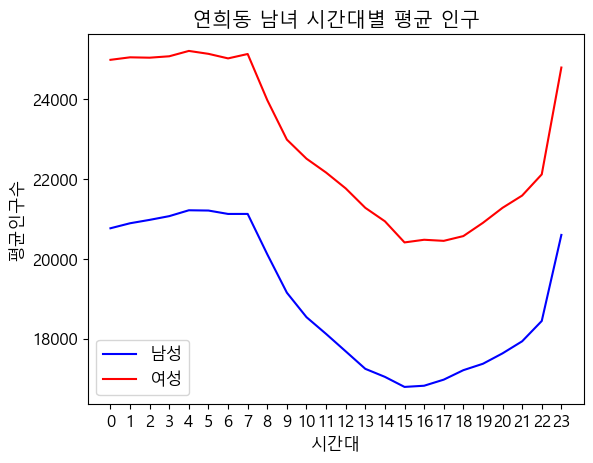

In [131]:
for row in data:
    for i in range(0, 32):
        if i <= 2:       # 인덱스가 2 이하인 경우 정수형으로 변환
            row[i] = int(row[i])
        else:            # 인덱스가 2 초과인 경우 실수형으로 변환
            row[i] = float(row[i])

print(data[0])
male = [0 for i in range(24)]
female = [0 for i in range(24)]

for row in data:
    if row[2] == dong_code:
        time = row[1]
        male[time] += sum(row[4:18])      # 남성 인구 종합 구하기
        female[time] += sum(row[18:32])   # 여성 인구 종합 구하기

male = [m/7 for m in male]
female = [f/7 for f in female]

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title(dong_name + ' 남녀 시간대별 평균 인구')
plt.plot(range(24), male, color = 'b', label='남성')
plt.plot(range(24), female, color = 'r', label='여성')
plt.xlabel('시간대')
plt.ylabel('평균인구수')
plt.legend()
plt.xticks(range(24), range(24))
plt.show()

핫플레이스가 위치한 행정동을 입력하세요 -->  연희동
비교할 행정동을 입력하세요 -->  압구정동


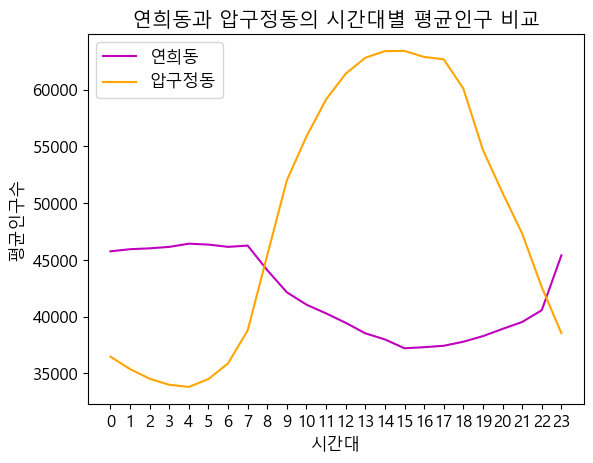

In [119]:
# 핫플레이스가 있는 행정동
dong_name = input('핫플레이스가 위치한 행정동을 입력하세요 --> ')
for row in code_data:
    if row[-1] == dong_name:
        dong_code = row[1]

# 비교할 행정동
dong_name2 = input('비교할 행정동을 입력하세요 --> ')
for row in code_data:
    if row[-1] == dong_name2:
        dong_code2 = row[1]
population = [0 for i in range(24)]
population2 = [0 for i in range(24)]

for row in data:
    # 핫플레이스가 있는 행정동인 경우
    if row[2] == dong_code:
        time, p = row[1], row[3]
        population[time] += p
        
    # 비교할 지역의 행정동인 경우
    elif row[2] == dong_code2:
        time, p = row[1], row[3]
        population2[time] += p

# 7일(일주일)로 나누어 평균 인구 계산
population = [p/7 for p in population]
population2 = [p/7 for p in population2]

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title(dong_name + '과 ' + dong_name2 + '의 시간대별 평균인구 비교')
plt.plot(range(24), population, color = 'm', label = dong_name)
plt.plot(range(24), population2, color = 'orange', label = dong_name2)
plt.legend()
plt.xlabel('시간대')
plt.ylabel('평균인구수')
plt.xticks(range(24), range(24))
plt.show()

In [134]:
# from tkinter import *
import csv 
import datetime
import matplotlib.pyplot as plt

# 전역 변수
dong_name1, dong_code1 = '', ''   # 핫플레이스가 있는 행정동명과 행정동코드
dong_name2, dong_code2 = '', ''   # 비교할 행정동명과 행정동코드

#################################################
# ----- 프로그램 기능 부분 -----
#################################################

#-------------------------------
# 1. 파일 읽기
#-------------------------------

def file_open():
    f = open('LOCAL_PEOPLE_DONG_201912.csv', encoding='utf8') # 또는 'eur-kr', 'CP949'
    data = csv.reader(f)
    next(data)
    data = list(data)

    f2 = open('dong_code.csv', encoding = 'utf8') # 또는 'eur-kr', 'CP949'
    code_data = csv.reader(f2)
    next(code_data)
    next(code_data)
    code_data = list(code_data)

    for row in data: 
        for i in range(1, 32): 
            if i <= 2:
                row[i] = int(row[i])
            else:
                row[i] = float(row[i])

    for row in code_data: 
        row[1] = int(row[1])

    return data, code_data

#-------------------------------
# 2. 행정동코드 찾기
#-------------------------------
def dong_search1(): 
    global dong_name1, dong_code1
    dong_name1 = dong_ent1.get()
    
    for row in code_data: 
        if row[-1] == dong_name1:
            dong_code1 = row[1]
    info.set(dong_name1 + '-' + str(dong_code1) + '를 분석합니다!')
    
# 비교할 행정동명을 행정동코드(dong_code2)로 변환하는 함수
def dong_search2(): 
    global dong_name2, dong_code2
    dong_name2 = dong_ent2.get()
    
    for row in code_data: 
        if row[-1] == dong_name2: 
            dong_code2 = row[1]  

    info.set(dong_name1 + '과 '+ dong_name2 + '를 비교합니다!')

#-------------------------------
# 3. 그래프 그리는 함수
#-------------------------------
def graph_plot(popu_list, label_list, graph_title):
    plt.figure(figsize=(10, 5)) # 그래프 크기 설정
    plt.rc('font', family='Malgun Gothic')
    plt.title(graph_title)
    for i in range(len(popu_list)): 
        plt.plot(range(24), popu_list[i], label=label_list[i])
    plt.legend()
    plt.xlabel('시간대')
    plt.ylabel('평균인구수')
    plt.xticks(range(24), range(24))
    plt.savefig('graph.png') # 결과 그래프를 이미지로 저장하기
    plt.show()

    # 그래프 이미지를 PhotoImage의 객체로 만들고, graph_lbl 레이블에 표시하기
    graph_img = PhotoImage(file='graph.png')
    graph_lbl.configure(image=graph_img)
    graph_lbl.image = graph_img

#-------------------------------
# 하위목표 1
#-------------------------------
def analysis1(graph_yn = 'y'):
    population = [0 for i in range(24)]
    for row in data: 
        if row[2] == dong_code1: 
            time, p = row[1], row[3]
            population[time] += p
    population = [p/31 for p in population]
    if graph_yn == 'n': 
        return population

    population = [population]
    labels = ['평균인구']
    title = dong_name1 + ' 시간대별 평균인구'
    graph_plot(popu_list = population, label_list = labels, graph_title = title)

#-------------------------------    
# 하위목표 2
#-------------------------------
def analysis2(): 
    # 4.1 입력된 행정동의 주중/주말 시간대별 평균인구 구하기
    weekday = [0 for i in range(24)]
    weekend = [0 for i in range(24)]

    for row in data: 
        if row[2] == dong_code1: 
            time, p = row[1], row[3]
            year, mon, day = int(row[0][:4]), int(row[0][4:6]), int(row[0][6:])
            num = datetime.date(year, mon, day).weekday()
            if num < 5: 
                weekday[time] += p
            else: 
                weekend[time] += p
 
    weekday_cnt, weekend_cnt = 0, 0
    for i in range(1, 32): 
        if datetime.date(2019,12,i).weekday() < 5:
            weekday_cnt += 1
        else: 
            weekend_cnt += 1

    weekday = [w/weekday_cnt for w in weekday]
    weekend = [w/weekend_cnt for w in weekend]

    # 4.2 4.1에서 구한 평균인구 리스트로 꺾은선 그래프 그리기 
    data_set = [weekday, weekend]
    labels = ['주중', '주말']
    title = dong_name1 + ' 주중/주말 시간대별 평균인구'
    graph_plot(popu_list = data_set, label_list = labels, graph_title = title)

#-------------------------------
# 하위목표 3
#-------------------------------
def analysis3(): 
    # 5.1 입력된 행정동의 남/녀 시간대별 평균인구 구하기
    male = [0 for i in range(24)]
    female = [0 for i in range(24)]

    for row in data: 
        if row[2] == dong_code1: 
            time = int(row[1])
            male[time] += sum(row[4:18])
            female[time] += sum(row[18:32])
    male = [m/31 for m in male]
    female = [f/31 for f in female]

    # 5.2 5.1에서 구한 평균인구 리스트로 꺾은선 그래프 그리기
    data_set = [male, female]
    labels = ['남성', '여성']
    title = dong_name1 + ' 남녀 시간대별 평균인구'
    graph_plot(popu_list = data_set, label_list = labels, graph_title = title)

#-------------------------------
# 하위목표 4
#-------------------------------
def analysis4():
    population1 = analysis1(graph_yn = 'n')
    population2 = [0 for i in range(24)]
    for row in data: 
        if row[2] == dong_code2: 
            time, p = row[1], row[3] 
            population2[time] += p
    population2 = [p/31 for p in population2]

    data_set = [population1, population2]
    labels = [dong_name1, dong_name2]
    title = dong_name1 + '과' + dong_name2 + ' 시간대별 평균인구'
    graph_plot(popu_list = data_set, label_list = labels, graph_title = title)


#################################################
# 프로그램 실행 부분
#################################################
data, code_data = file_open() 


#################################################
# ----- 프로그램 화면 부분 -----
#################################################

root = Tk()
root.geometry('800x500')
root.title('핫플레이스는 언제 가야 가장 덜 붐빌까?')

#-------------------------------
# ----- 프레임 -----
#-------------------------------
Menu = Frame(root)
Menu.grid(row=0, column=0)
Graph = Frame(root)
Graph.grid(row=1, column=0)

#-------------------------------
# ----- 메뉴 프레임 -----1
#-------------------------------
dong_ent1 = Entry(Menu, width=20)
dong_ent1.grid(row=0, column=0)

dong_btn1 = Button(Menu, text='핫플레이스 행정동 설정', width=20, command=dong_search1)
dong_btn1.grid(row=0, column=1)

dong_ent2 = Entry(Menu, width=20)
dong_ent2.grid(row=0, column=2)

dong_btn2 = Button(Menu, text='비교할 행정동 설정', width=20, command=dong_search2)
dong_btn2.grid(row=0, column=3)

info = StringVar()
dong_lbl = Label(Menu, textvariable=info, font=('Malgun Gothic', 12))
dong_lbl.grid(row=1, columnspan=4)

#-------------------------------
# ----- 그래프 프레임 -----
#-------------------------------
btn1 = Button(Graph, text='1. 시간대별 그래프', width=20, command=analysis1)
btn1.grid(row=0, column=0)

btn2 = Button(Graph, text='2. 주중/주말 그래프', width=20, command=analysis2)
btn2.grid(row=0, column=1)

btn3 = Button(Graph, text='3. 남/녀 그래프', width=20, command=analysis3)
btn3.grid(row=0, column=2)

btn4 = Button(Graph, text='4. 지역별 그래프', width=20, command=analysis4)
btn4.grid(row=0, column=3)

graph_lbl = Label(Graph)
graph_lbl.grid(row=1, column=0, columnspan=5)

root.mainloop()